<a href="https://colab.research.google.com/github/pgordin/OptDisc2026/blob/main/grafy_wa%C5%BCone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from random import random, seed
from copy import deepcopy

In [2]:
# @title
def print_matrix(vertices, matrix):
  """
  Wypisuje na ekranie graf podany jako macierz sąsiedztwa
  """
  n = len(matrix)
  if (vertices is None) or (len(vertices) != n):
    vv = range(1, n+1)
  else:
    vv = vertices
  for i in range(n):
    print(vv[i], ':', end='')
    for j in range(n):
      if (matrix[i][j]):
        print(" ", vv[j], end="")
    print("")


In [3]:
# @title
def print_dict(graph):
  """
  Wypisuje na ekranie graf podany jako słownik (list) sąsiedztwa
  """
  for v in graph:
    print(v, ':', end="")
    for u in graph[v]:
      print(" ", u, end="")
    print("")

In [ ]:
# @title
class Graph:
    def __init__(self, graph=None):
        if graph is None:
            graph = {}
        self.graph = graph

    # inicjalizator ze słownika
    @classmethod
    def from_dict(cls, graph):
        return cls(graph)

    # inicjalizator z macierzy
    @classmethod
    def from_matrix(cls, matrix, vertices = None):
        if (vertices is None) or (len(vertices) != len(matrix)):
            vertices = [*range(1, len(matrix) + 1)]
        return cls.from_dict(cls._matrix_to_dict(matrix, vertices))

    # dwie prywatne metody macierz <-> słownik
    def _matrix_to_dict(matrix, vertices: list) -> dict:
        """
        Zamienia graf podany jako macierz sąsiedztwa na słownik sąsiedztwa.
        """
        res_dict = {}
        for i, v in enumerate(vertices):
            neighbours = [vertices[j] for j, edge in enumerate(matrix[i]) if edge]
            res_dict[v] = neighbours
        return res_dict

    def _dict_to_matrix(self, _dict: dict) -> np.array:
        """
        Zamienia graf podany jako słownik sąsiedztwa na macierz sąsiedztwa.
        """
        n = len(_dict)
        vertices = [*_dict.keys()]
        matrix = np.zeros(shape = (n, n), dtype=int)
        for u,v in [
            (vertices.index(u), vertices.index(v))
            for u, row in _dict.items() for v in row
        ]:
            matrix[u][v] += 1
        return matrix

    def vertices(self) -> list:
        """
        Zwraca listę wierzchołków grafu.
        """
        return [*self.graph.keys()]

    def matrix(self) -> np.array:
        """
        Zwraca macierz sąsiedztwa grafu.
        """
        return self._dict_to_matrix(self.graph)

    # przedefiniowania sposobu wyświetlania grafów
    def __str__(self):
        res = ""
        for v in self.graph:
            res += f"{v}:"
            for u in self.graph[v]:
                res += f" {u}"
            res += "\n"
        return res

    # Poniższe dostajemy za darmo z powyższego
    def to_neighbourlist(self, filename: str):
        """
        Zapisuje graf podany jako słownik (list) sąsiedztwa do pliku (w formie listy sąsiedztwa).
        Zmienna filename zawiera pełną ścieżkę pliku
        """
        file = open(filename, "w")  # otwarcie pliku tekstowego do zapisu
        file.write(str(self))
        file.close()

    # rysowanie grafów
    def plot(self, directed=0):
        """
        Rysuje graf używając metod biblioteki networkx.
        """
        if directed:
            G = nx.DiGraph(self.graph)
        else:
          G = nx.Graph(self.graph)
        pos = nx.spring_layout(G)
        nx.draw(G, pos, with_labels=True)
        plt.show()


    # Modyfikacje grafów
    def add_vertex(self, vertex):
        """
        Dodaje wierzchołek do grafu
        """
        if vertex not in self.graph:
            self.graph[vertex] = []

    def del_vertex(self, vertex):
        """
        Usuwa wierzchołek z grafu
        """
        if vertex in self.graph:
            self.graph.pop(vertex)
            for u in self.graph:
                if vertex in self.graph[u]:
                    self.graph[u].remove(vertex)

    def add_arc(self, arc):
        """
        Dodaje łuk (skierowany, podany jako para wierzchołków) do grafu
        """
        u, v = arc
        self.add_vertex(u)
        self.add_vertex(v)
        if v not in self.graph[u]:
            self.graph[u].append(v)

    def add_edge(self, edge: list):
        """
        Dodaje krawędź (podaną jako para wierzchołków) do grafu
        Rozpatrujemy grafy proste, nieskierowane
        """
        u, v = edge
        if u == v:
            raise ValueError("Pętle nie są dopuszczalne!")
        self.add_vertex(u)
        self.add_vertex(v)
        if v not in self.graph[u]:
            self.graph[u].append(v)
        if u not in self.graph[v]:
            self.graph[v].append(u)

    # czytanie z plików
    @staticmethod
    def from_edges(filename: str, directed = 0):
        """
        Tworzy graf na podstawie pliku z łukami/krawędziami.
        Opis łuku/krawędzi to dwa słowa lub wierzchołka (jedno słowo).
        Nadmiarowe słowa są ignorowane.
        Zmienna filename zawiera pełną ścieżkę pliku
        """
        graph = Graph()
        file = open(filename, "r")          # otwarcie pliku do odczytu
        for line in file:                   # dla każdej linii w pliku
          words = line.strip().split()      # rozdziel linię na słowa
          if len(words) == 1:               # jedno słowo - opis wierzchołka
            graph.add_vertex(words[0])
          elif len(words) >= 2:             # conajmnej 2 słowa - opis krawędzi/łuku
            if directed:
              graph.add_arc([words[0], words[1]])
            else:
              graph.add_edge([words[0], words[1]])
        file.close()
        return graph

    def to_edges(self, filename, directed=1):
      """
      Zapisuje graf podany jako słownik (list) sąsiedztwa do pliku (w formie listy krawędzi).
      Zapis jako grafd skierowany lub nieskierowany zależy od wartości zmiennej directed.
      Zmienna filename zawiera pełną ścieżkę pliku
      """
      with open(filename,"w") as file:
        wierzcholki = list(self.graph.keys())
        for v in self.graph:
          if len(self.graph[v]) > 0:
            for u in self.graph[v]:
              if ((directed) or (wierzcholki.index(v) < wierzcholki.index(u))):
                line = f"{v} {u}\n"
                file.write(line)
          else:
                file.write(v + "\n")

    @staticmethod
    def from_neighbourlist(filename, directed=0):
      """
      Tworzy graf na podstawie pliku z listą sąsiedztwa.
      Zmienna filename zawiera pełną ścieżkę pliku
      """
      graph = Graph()
      with open(filename, 'r') as file:
        for line in file:
          line = line.replace(":", "")
          words = list(line.strip().split())
          graph.add_vertex(words[0])
          for i in range(1,len(words)):
            if directed:
              graph.add_arc((words[0],words[i]))
            else:
              graph.add_edge((words[0],words[i]))
      return graph

    @staticmethod
    def random_graph(n: int, p: float):
        """
        Tworzy losowy graf nieskierowany G(n,p)
        """
        rand_graph = Graph()
        for i in range(1, n + 1):
            rand_graph.add_vertex(i)
            for j in range(1, i):
                if random() < p:
                    rand_graph.add_edge([i, j])
        return rand_graph

    @staticmethod
    def cycle(n: int):
        """
        Tworzy graf cykliczny o n wierzchołkach
        """
        cycle = Graph()
        for i in range(n-1):
          cycle.add_edge([i+1, i+2])
        cycle.add_edge([1, n])
        return cycle

    def Prufer(self):
        """
        Zwraca kod Prüfera drzewa.
        Nie jest sprawdzane, czy graf jest drzewem. Dla nie drzew może działać źle.
        Wynik podany jako napis (pusty gdy jest mniej niż 3 wierzchołki).
        """
        tr = deepcopy(self.graph)   # kopia słownika grafu
        code = ""
        for i in range(len(self.graph)-2):
          for x in sorted(tr):
            if len(tr[x])==1:     # najmniejszy liść
              break
          v = tr[x][0]            # sąsiad najmniejszego liścia
          code += f"{v} "
          tr.pop(x)
          tr[v].remove(x)
        return code.strip()

    @staticmethod
    def tree_from_Prufer(code :str):
      """
      Tworzy drzewo z kodu Prüfera
      """
      tree = Graph()
      clist = [int(x) for x in code.strip().split()]  # kod jako lista liczb
      n = len(clist) + 2    # liczba wierzchołków
      vert = [*range(1, n + 1)]
      for v in vert:
        tree.add_vertex(v)
      for i in range(n-2):
        for x in vert:
          if x not in clist:    # najmniejszy liść
            break
        v = clist.pop(0)  # sąsiad najmniejszego liścia
        tree.add_edge([x, v])
        vert.remove(x)
      tree.add_edge(vert) # na liście vert zostały 2 elementy - ostatnia krawędź
      return tree















      #praca domowa
    def preorder(self, v, visited=None):
      if visited is None:
          visited = set()

      visited.add(v)
      print(v, end=" ")

      for u in self.graph[v]:
          if u not in visited:
              self.preorder(u, visited)
    def postorder(self, v, visited=None):
      if visited is None:
         visited = set()

      visited.add(v)

      for u in self.graph[v]:
        if u not in visited:
           self.postorder(u, visited)

      print(v, end=" ")

     #graf losowy dwudzielny może być bardzo różny i niespójny
    @staticmethod
    def random_bipartite_graph(n: int, p: float):
      #pusty graf
      g = Graph()

    # podział na dwie grafy
      A = list(range(1, n + 1))
      B = list(range(n + 1, 2*n + 1))

    # wierzchołki
      for v in A + B:
         g.add_vertex(v)

    # losowe krawędzie
      for u in A:
        for v in B:
          if random() < p:
               g.add_edge([u, v])

      return g


      #część 5
    def ConnectedComponentsBFS(self):

        #Zwraca listę spójnych składowych grafu wykorzystując BFS.


        visited = set()
        components = []

        for v in self.graph:
            if v not in visited:

                component = set([v])
                visited.add(v)

                queue = [v]

                while queue:
                    u = queue.pop(0)

                    for w in self.graph[u]:
                        if w not in visited:
                            visited.add(w)
                            component.add(w)
                            queue.append(w)

                components.append(component)

        return components

    def TopologicalSort(self):

        #Sortowanie topologiczne grafu skierowanego.


        visited = set()
        result = []

        def DFS(v):
            visited.add(v)

            for u in self.graph[v]:
                if u not in visited:
                    DFS(u)

            result.append(v)

        for v in self.graph:
            if v not in visited:
                DFS(v)

        result.reverse()
        return result

    def StronglyConnectedComponents(self):
        """
        Zwraca silnie spójne składowe grafu skierowanego.
        Algorytm Kosaraju.
        """

        visited = set()
        order = []

        # pierwszy DFS
        def DFS1(v):
            visited.add(v)

            for u in self.graph[v]:
                if u not in visited:
                    DFS1(u)

            order.append(v)

        for v in self.graph:
            if v not in visited:
                DFS1(v)

        # odwrócenie grafu
        reversed_graph = Graph()

        for v in self.graph:
            reversed_graph.add_vertex(v)

        for v in self.graph:
            for u in self.graph[v]:
                reversed_graph.add_arc((u, v))

        # drugi DFS
        visited.clear()
        components = []

        def DFS2(v, component):
            visited.add(v)
            component.append(v)

            for u in reversed_graph.graph[v]:
                if u not in visited:
                    DFS2(u, component)

        while order:
            v = order.pop()

            if v not in visited:
                component = []
                DFS2(v, component)
                components.append(component)

        return components

In [9]:
import numpy as np
#klasa grafów ważonych
from queue import PriorityQueue
import networkx as nx # Added for Graph.plot
import matplotlib.pyplot as plt # Added for Graph.plot
from random import random, seed # Added for Graph.random_graph
from copy import deepcopy # Added for Graph.Prufer

class Graph:
    def __init__(self, graph=None):
        if graph is None:
            graph = {}
        self.graph = graph

    # inicjalizator ze słownika
    @classmethod
    def from_dict(cls, graph):
        return cls(graph)

    # inicjalizator z macierzy
    @classmethod
    def from_matrix(cls, matrix, vertices = None):
        if (vertices is None) or (len(vertices) != len(matrix)):
            vertices = [*range(1, len(matrix) + 1)]
        return cls.from_dict(cls._matrix_to_dict(matrix, vertices))

    # dwie prywatne metody macierz <-> słownik
    def _matrix_to_dict(matrix, vertices: list) -> dict:
        """
        Zamienia graf podany jako macierz sąsiedztwa na słownik sąsiedztwa.
        """
        res_dict = {}
        for i, v in enumerate(vertices):
            neighbours = [vertices[j] for j, edge in enumerate(matrix[i]) if edge]
            res_dict[v] = neighbours
        return res_dict

    def _dict_to_matrix(self, _dict: dict) -> np.array:
        """
        Zamienia graf podany jako słownik sąsiedztwa na macierz sąsiedztwa.
        """
        n = len(_dict)
        vertices = [*_dict.keys()]
        matrix = np.zeros(shape = (n, n), dtype=int)
        for u,v in [
            (vertices.index(u), vertices.index(v))
            for u, row in _dict.items() for v in row
        ]:
            matrix[u][v] += 1
        return matrix

    def vertices(self) -> list:
        """
        Zwraca listę wierzchołków grafu.
        """
        return [*self.graph.keys()]

    def matrix(self) -> np.array:
        """
        Zwraca macierz sąsiedztwa grafu.
        """
        return self._dict_to_matrix(self.graph)

    # przedefiniowania sposobu wyświetlania grafów
    def __str__(self):
        res = ""
        for v in self.graph:
            res += f"{v}:"
            for u in self.graph[v]:
                res += f" {u}"
            res += "\n"
        return res

    # Poniższe dostajemy za darmo z powyższego
    def to_neighbourlist(self, filename: str):
        """
        Zapisuje graf podany jako słownik (list) sąsiedztwa do pliku (w formie listy sąsiedztwa).
        Zmienna filename zawiera pełną ścieżkę pliku
        """
        file = open(filename, "w")  # otwarcie pliku tekstowego do zapisu
        file.write(str(self))
        file.close()

    # rysowanie grafów
    def plot(self, directed=0):
        """
        Rysuje graf używając metod biblioteki networkx.
        """
        if directed:
            G = nx.DiGraph(self.graph)
        else:
          G = nx.Graph(self.graph)
        pos = nx.spring_layout(G)
        nx.draw(G, pos, with_labels=True)
        plt.show()


    # Modyfikacje grafów
    def add_vertex(self, vertex):
        """
        Dodaje wierzchołek do grafu
        """
        if vertex not in self.graph:
            self.graph[vertex] = []

    def del_vertex(self, vertex):
        """
        Usuwa wierzchołek z grafu
        """
        if vertex in self.graph:
            self.graph.pop(vertex)
            for u in self.graph:
                if vertex in self.graph[u]:
                    self.graph[u].remove(vertex)

    def add_arc(self, arc):
        """
        Dodaje łuk (skierowany, podany jako para wierzchołków) do grafu
        """
        u, v = arc
        self.add_vertex(u)
        self.add_vertex(v)
        if v not in self.graph[u]:
            self.graph[u].append(v)

    def add_edge(self, edge: list):
        """
        Dodaje krawędź (podaną jako para wierzchołków) do grafu
        Rozpatrujemy grafy proste, nieskierowane
        """
        u, v = edge
        if u == v:
            raise ValueError("Pętle nie są dopuszczalne!")
        self.add_vertex(u)
        self.add_vertex(v)
        if v not in self.graph[u]:
            self.graph[u].append(v)
        if u not in self.graph[v]:
            self.graph[v].append(u)

    # czytanie z plików
    @staticmethod
    def from_edges(filename: str, directed = 0):
        """
        Tworzy graf na podstawie pliku z łukami/krawędziami.
        Opis łuku/krawędzi to dwa słowa lub wierzchołka (jedno słowo).
        Nadmiarowe słowa są ignorowane.
        Zmienna filename zawiera pełną ścieżkę pliku
        """
        graph = Graph()
        file = open(filename, "r")          # otwarcie pliku do odczytu
        for line in file:                   # dla każdej linii w pliku
          words = line.strip().split()      # rozdziel linię na słowa
          if len(words) == 1:               # jedno słowo - opis wierzchołka
            graph.add_vertex(words[0])
          elif len(words) >= 2:             # conajmnej 2 słowa - opis krawędzi/łuku
            if directed:
              graph.add_arc([words[0], words[1]])
            else:
              graph.add_edge([words[0], words[1]])
        file.close()
        return graph

    def to_edges(self, filename, directed=1):
      """
      Zapisuje graf podany jako słownik (list) sąsiedztwa do pliku (w formie listy krawędzi).
      Zapis jako grafd skierowany lub nieskierowany zależy od wartości zmiennej directed.
      Zmienna filename zawiera pełną ścieżkę pliku
      """
      with open(filename,"w") as file:
        wierzcholki = list(self.graph.keys())
        for v in self.graph:
          if len(self.graph[v]) > 0:
            for u in self.graph[v]:
              if ((directed) or (wierzcholki.index(v) < wierzcholki.index(u))):
                line = f"{v} {u}\n"
                file.write(line)
          else:
                file.write(v + "\n")

    @staticmethod
    def from_neighbourlist(filename, directed=0):
      """
      Tworzy graf na podstawie pliku z listą sąsiedztwa.
      Zmienna filename zawiera pełną ścieżkę pliku
      """
      graph = Graph()
      with open(filename, 'r') as file:
        for line in file:
          line = line.replace(":", "")
          words = list(line.strip().split())
          graph.add_vertex(words[0])
          for i in range(1,len(words)):
            if directed:
              graph.add_arc((words[0],words[i]))
            else:
              graph.add_edge((words[0],words[i]))
      return graph

    @staticmethod
    def random_graph(n: int, p: float):
        """
        Tworzy losowy graf nieskierowany G(n,p)
        """
        rand_graph = Graph()
        for i in range(1, n + 1):
            rand_graph.add_vertex(i)
            for j in range(1, i):
                if random() < p:
                    rand_graph.add_edge([i, j])
        return rand_graph

    @staticmethod
    def cycle(n: int):
        """
        Tworzy graf cykliczny o n wierzchołkach
        """
        cycle = Graph()
        for i in range(n-1):
          cycle.add_edge([i+1, i+2])
        cycle.add_edge([1, n])
        return cycle

    def Prufer(self):
        """
        Zwraca kod Prüfera drzewa.
        Nie jest sprawdzane, czy graf jest drzewem. Dla nie drzew może działać źle.
        Wynik podany jako napis (pusty gdy jest mniej niż 3 wierzchołki).
        """
        tr = deepcopy(self.graph)   # kopia słownika grafu
        code = ""
        for i in range(len(self.graph)-2):
          for x in sorted(tr):
            if len(tr[x])==1:     # najmniejszy liść
              break
          v = tr[x][0]            # sąsiad najmniejszego liścia
          code += f"{v} "
          tr.pop(x)
          tr[v].remove(x)
        return code.strip()

    @staticmethod
    def tree_from_Prufer(code :str):
      """
      Tworzy drzewo z kodu Prüfera
      """
      tree = Graph()
      clist = [int(x) for x in code.strip().split()]  # kod jako lista liczb
      n = len(clist) + 2    # liczba wierzchołków
      vert = [*range(1, n + 1)]
      for v in vert:
        tree.add_vertex(v)
      for i in range(n-2):
        for x in vert:
          if x not in clist:    # najmniejszy liść
            break
        v = clist.pop(0)  # sąsiad najmniejszego liścia
        tree.add_edge([x, v])
        vert.remove(x)
      tree.add_edge(vert) # na liście vert zostały 2 elementy - ostatnia krawędź
      return tree















      #praca domowa
    def preorder(self, v, visited=None):
      if visited is None:
          visited = set()

      visited.add(v)
      print(v, end=" ")

      for u in self.graph[v]:
          if u not in visited:
              self.preorder(u, visited)
    def postorder(self, v, visited=None):
      if visited is None:
         visited = set()

      visited.add(v)

      for u in self.graph[v]:
        if u not in visited:
           self.postorder(u, visited)

      print(v, end=" ")

     #graf losowy dwudzielny może być bardzo różny i niespójny
    @staticmethod
    def random_bipartite_graph(n: int, p: float):
      #pusty graf
      g = Graph()

    # podział na dwie grafy
      A = list(range(1, n + 1))
      B = list(range(n + 1, 2*n + 1))

    # wierzchołki
      for v in A + B:
         g.add_vertex(v)

    # losowe krawędzie
      for u in A:
        for v in B:
          if random() < p:
               g.add_edge([u, v])

      return g


      #część 5
    def ConnectedComponentsBFS(self):

        #Zwraca listę spójnych składowych grafu wykorzystując BFS.


        visited = set()
        components = []

        for v in self.graph:
            if v not in visited:

                component = set([v])
                visited.add(v)

                queue = [v]

                while queue:
                    u = queue.pop(0)

                    for w in self.graph[u]:
                        if w not in visited:
                            visited.add(w)
                            component.add(w)
                            queue.append(w)

                components.append(component)

        return components

    def TopologicalSort(self):

        #Sortowanie topologiczne grafu skierowanego.


        visited = set()
        result = []

        def DFS(v):
            visited.add(v)

            for u in self.graph[v]:
                if u not in visited:
                    DFS(u)

            result.append(v)

        for v in self.graph:
            if v not in visited:
                DFS(v)

        result.reverse()
        return result

    def StronglyConnectedComponents(self):
        """
        Zwraca silnie spójne składowe grafu skierowanego.
        Algorytm Kosaraju.
        """

        visited = set()
        order = []

        # pierwszy DFS
        def DFS1(v):
            visited.add(v)

            for u in self.graph[v]:
                if u not in visited:
                    DFS1(u)

            order.append(v)

        for v in self.graph:
            if v not in visited:
                DFS1(v)

        # odwrócenie grafu
        reversed_graph = Graph()

        for v in self.graph:
            reversed_graph.add_vertex(v)

        for v in self.graph:
            for u in self.graph[v]:
                reversed_graph.add_arc((u, v))

        # drugi DFS
        visited.clear()
        components = []

        def DFS2(v, component):
            visited.add(v)
            component.append(v)

            for u in reversed_graph.graph[v]:
                if u not in visited:
                    DFS2(u, component)

        while order:
            v = order.pop()

            if v not in visited:
                component = []
                DFS2(v, component)
                components.append(component)

        return components


class WeightedGraph(Graph):
    def __init__(self, graph=None, weights=None):
        if weights is None:
            weights = {}
        self.weights = weights
        super().__init__(graph)

    # inicjalizator ze słownika
    @classmethod
    def from_dict(cls, graph, weights):
        return cls(graph, weights)

    # przedefiniowania sposobu wyświetlania grafów
    def __str__(self):
        res = ""
        for v in self.graph:
            res += f"{v}:"
            for u in self.graph[v]:
                res += f" {u}({self.weights[(v, u)]})"
            res += "\n"
        return res

   # rysowanie grafów
    def plot(self, directed=0):
        """
        Rysuje graf ważony używając metod biblioteki networkx.
        """
        if directed:
            G = nx.DiGraph(self.graph)
        else:
          G = nx.Graph(self.graph)
        for u,v in self.weights:
          G.edges[u,v]['weight'] = self.weights[(u,v)]
        pos = nx.spring_layout(G)
        labels = nx.get_edge_attributes(G,'weight')
        nx.draw(G, pos, with_labels=True)
        nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
        plt.show()

    def add_arc(self, arc, weight = 1):
        """
        Dodaje łuk (skierowany, podany jako para wierzchołków) do grafu
        """
        super().add_arc(arc)
        self.weights[arc] = weight

    def add_edge(self, edge: list, weight = 1):
        """
        Dodaje krawędź (podaną jako para wierzchołków) do grafu
        Rozpatrujemy grafy proste, nieskierowane
        """
        u, v = edge
        super().add_edge(edge)
        self.weights[(u, v)] = weight
        self.weights[(v, u)] = weight

    # czytanie z plików
    @staticmethod
    def from_edges(filename: str, directed = 0):
        """
        Tworzy graf na podstawie pliku z łukami/krawędziami.
        Opis łuku/krawędzi to dwa słowa lub wierzchołka (jedno słowo),
        albo 3 słowa: wierzchołek, wierzchołek, waga.
        Nadmiarowe słowa są ignorowane.
        Zmienna filename zawiera pełną ścieżkę pliku
        """
        wgraph = WeightedGraph()
        file = open(filename, "r")          # otwarcie pliku do odczytu
        for line in file:                   # dla każdej linii w pliku
          words = line.strip().split()      # rozdziel linię na słowa
          if len(words) == 1:               # jedno słowo - opis wierzchołka
            wgraph.add_vertex(words[0])
          elif len(words) == 2:             # 2 słowa - opis krawędzi/łuku bez wag
            if directed:
              graph.add_arc([words[0], words[1]])
            else:
              graph.add_edge([words[0], words[1]])
          elif len(words) >= 3:             # co najmniej 3 słowa - opis krawędzi/łuku z wagami
            if directed:
              wgraph.add_arc([words[0], words[1]], int(words[2]))
            else:
              wgraph.add_edge([words[0], words[1]], int(words[2]))
        file.close()
        return wgraph


    def min_spanning_tree(self):
        """
        Zwraca drzewo rozpinające wg algorytmu Jarnika-Prima.
        """
        for v in self.graph:
          break
        wtree = WeightedGraph({v: []})
        total = 0     # łączna waga drzewa
        pq = PriorityQueue()
        for u in self.graph[v]:
          pq.put((self.weights[(v, u)], v, u))
        while not pq.empty():
          w, v, u = pq.get()
          if not u in wtree.graph:
            wtree.add_edge((u, v), w)
            total += w
            for x in self.graph[u]:
              if not x in wtree.graph:
                pq.put((self.weights[(u, x)], u, x))
        if len(wtree.graph) < len(self.graph):
          print("Graf niespojny! Zwrócono drzewo dla jednej spójnej składowej.")
        return wtree, total


    #praca domowa
    def matrix(self, empty=float('inf')):

        #Zwraca macierz wag grafu ważonego.
        #empty - nie ma krawędzi krawędzi


        vertices = list(self.graph.keys())
        n = len(vertices)

        index = {v: i for i, v in enumerate(vertices)}

        matrix = [[empty for _ in range(n)] for _ in range(n)]

        # odległość do siebie = 0
        for i in range(n):
            matrix[i][i] = 0

        # wpisanie wag
        for (u, v), w in self.weights.items():
            i = index[u]
            j = index[v]
            matrix[i][j] = w

        return vertices, matrix

    @classmethod
    def from_matrix(cls, matrix, vertices=None, empty=float('inf')):
        #odwrotność poprzedniej funkcji
        n = len(matrix)

        if vertices is None:
            vertices = list(range(1, n + 1))

        wgraph = cls()

        # dodaj wierzchołki
        for v in vertices:
            wgraph.add_vertex(v)

        # dodaj krawędzie
        for i in range(n):
            for j in range(n):

                if i != j and matrix[i][j] != empty:

                    wgraph.add_arc(
                        (vertices[i], vertices[j]),
                        matrix[i][j]
                    )

        return wgraph

    def FloydWarshall(self):
        """
        Zwraca macierz najkrótszych odległości  między wszystkimi parami wierzchołków.
        """

        vertices, dist = self.matrix(empty=float('inf'))

        n = len(vertices)
        #potrójna pętla
        for k in range(n):
            for i in range(n):
                for j in range(n):

                    if dist[i][k] + dist[k][j] < dist[i][j]:
                        dist[i][j] = dist[i][k] + dist[k][j]

        return vertices, dist


In [ ]:
# @title
t = Graph.tree_from_Prufer("4 4 4 5")

print("Preorder:")
t.preorder(1)
print("\n")
print("Postorder:")
t.postorder(1)

Preorder:
1 4 2 3 5 6 

Postorder:
2 3 6 5 4 1 

1: 5 6
2:
3:
4: 5 6
5: 1 4
6: 1 4
7:
8:



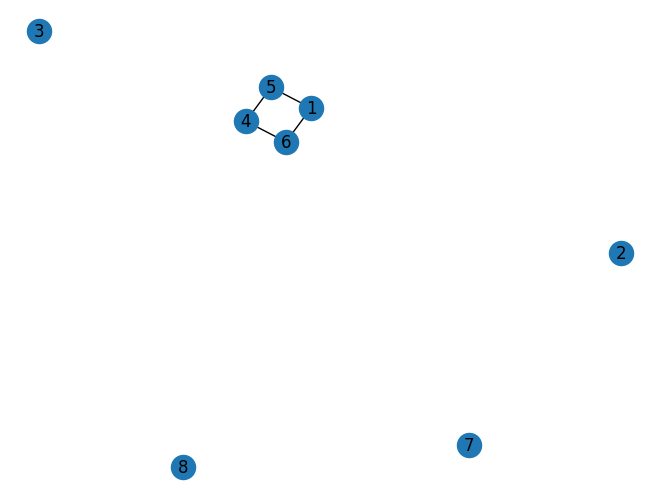

In [ ]:
# @title
g = Graph.random_bipartite_graph(4, 0.5)
print(g)
g.plot()
#za każdym razem losuje się inny graf, ale to celowo zostawiłam

In [ ]:
# @title
#klasy cz. 2 spójne składowe itp.
g1 = Graph()

g1.add_arc((1,2))
g1.add_arc((1,3))
g1.add_arc((2,4))
g1.add_arc((3,4))
    # algorytm Floyda-Warshalla

print(g1.TopologicalSort())
g2 = Graph()

g2.add_arc((1,2))
g2.add_arc((2,3))
g2.add_arc((3,1))

g2.add_arc((3,4))
g2.add_arc((4,5))
g2.add_arc((5,4))

print(g2.StronglyConnectedComponents())


[1, 3, 2, 4]
[[1, 3, 2], [4, 5]]


In [10]:
#przykład
g = WeightedGraph() #robi graf pusty ważony
#dodanie krawędzi i wierzchołków razem
g.add_edge((1,2), 4)
g.add_edge((1,3), 2)
g.add_edge((2,3), 1)
g.add_edge((2,4), 5)
g.add_edge((3,4), 8)

vertices, matrix = g.matrix()

print("Macierz ")
for row in matrix:
    print(row)
print("\n")
vertices, dist = g.FloydWarshall() #algorytm Floyda

print("Macierz odległości:")
for row in dist:
    print(row)

Macierz 
[0, 4, 2, inf]
[4, 0, 1, 5]
[2, 1, 0, 8]
[inf, 5, 8, 0]


Macierz odległości:
[0, 3, 2, 8]
[3, 0, 1, 5]
[2, 1, 0, 6]
[8, 5, 6, 0]
